<a href="https://colab.research.google.com/github/malakkhaledd3/new-repo/blob/main/Classification_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name:

ID:

Tutorial:

---

Name:

ID:

Tutorial:

---


## Dataset Description

The following dataset includes information about loan applicants, including factors such as income, credit score, employment status, loan details, and other indicators of financial stability, along with the final decision showing whether each loan was approved or not.

| Column | Description|
|-|-|
|ApplicationNumber|Unique identifier assigned to each loan application|
|Age|Applicant’s age in years|
|AnnualIncome|Applicant’s yearly income|
|CreditScore|A score representing the applicant’s creditworthiness|
|EmploymentStatus|Applicant’s current employment situation (Employed, Unemployed, Self-Employed)|
|EducationLevel|Highest educational qualification attained (Highschool, Bachelor, Master, Doctorate, Diploma)|
|LoanAmount|Total amount of money requested for the loan|
|LoanDuration|Duration of the loan in months|
|MaritalStatus|Applicant’s marital state (Divorced, Married, Single, Widowed)|
|NumberOfDependents|Number of individuals financially dependent on the applicant|
|HomeOwnershipStatus|Applicant’s housing status (Mortagage, Own, Rent, Other)|
|BankruptcyHistory|Indicates whether the applicant has previously declared bankruptcy (0 = No, 1 = Yes)|
|LoanPurpose|The primary reason for taking the loan (Debt Consolidation, Home Improvement, Education, Personal)|
|PreviousLoanDefaults|Indicates if the applicant has defaulted on any previous loans (0 = No, 1 = Yes)|
|MonthlyLoanPayment|Amount the applicant would need to pay monthly to repay the loan|
|MonthlyIncome|Average monthly income of the applicant|
|JobTenure|Number of years the applicant has been in their current job|
|LoanApproved|Indicates loan approval status (No = Not Approved, Yes = Approved)|

## Importing Libraries & Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')
df.head(50)

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No
5,25269,18,"$51,003.00",586,Self-Employed,Bachelor,"$17,497.00",72 months,Married,0,Other,0,Vehicle,0,NaN,NaN,3,No
6,10786,18,"$47,185.00",531,Unemployed,Diploma,"$18,490.00",48 months,Single,2,Rent,0,Home Improvement,1,NaN,"$3,932.08",3,No
7,20270,18,"$44,425.00",574,Employed,High School,"$33,360.00",24 months,Married,1,Mortgage,0,Home Improvement,0,"$1,390.00","$3,702.08",7,No
8,26864,18,"$40,600.00",479,Unemployed,Bachelor,"$18,544.00",48 months,Single,3,Mortgage,0,Education,1,$386.33,"$3,383.33",4,No
9,23279,18,"$15,000.00",621,Employed,Bachelor,"$10,255.00",48 months,Single,0,Other,0,Vehicle,0,$213.65,NaN,1,No


## Data Inspection

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')

print("DataFrame Shape:", df.shape)
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Description:")
print(df.describe())

DataFrame Shape: (20000, 18)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ApplicationNumber     20000 non-null  int64 
 1   Age                   20000 non-null  int64 
 2   AnnualIncome          20000 non-null  object
 3   CreditScore           20000 non-null  int64 
 4   EmploymentStatus      16260 non-null  object
 5   EducationLevel        20000 non-null  object
 6   LoanAmount            20000 non-null  object
 7   LoanDuration          20000 non-null  object
 8   MaritalStatus         20000 non-null  object
 9   NumberOfDependents    20000 non-null  int64 
 10  HomeOwnershipStatus   20000 non-null  object
 11  BankruptcyHistory     20000 non-null  int64 
 12  LoanPurpose           20000 non-null  object
 13  PreviousLoanDefaults  20000 non-null  int64 
 14  MonthlyLoanPayment    15660 non-null  ob

Data inspection( Justification)

The result of running the following three functions df.shape, df.info, and df.describe, provides us with a clear overall picture of how the data is organized, what kind of data it includes, and the general statistical trends. This is necessary prior to any cleaning or preprocessing as it informs us about what we should be fixing and what kind of transformation should be done.

DataFrame Shape

Shape: (20000, 18)
This implies that there are 20,000 rows and 18 columns. The size enables us to determine the size of the dataset which can be used to predict the level of load, the time the operations are likely to be completed and the type of processing we will require.

DataFrame Info

Based on the results of the df.info() call, the number of important observations are as follows:

Data Types

The combination of the types is int64 and object.

The use of numerical values like ApplicationNumber, Age, CreditScore, NumberOfDependents, BankruptcyHistory, PreviousLoanDefaults, and JobTenure is identified as integers correctly.

Nevertheless, a lot of the columns that are supposed to be numerical (e.g. AnnualIncome, LoanAmount, MonthlyLoanPayment, MonthlyIncome) are represented as object.
This typically translates to the fact that they have non-numeric values such as dollar or commas thus, should be cleaned and changed to numbers.

Missing Values

When the non-null counts are compared to the total counts (20,000 rows) we can observe the following missing values:

EmploymentStatus: 3740 values are missing.

MonthlyLoanPayment: there are 4340 spaces in the column.

MonthlyIncome: 2840 values are missing.

The missing values will have to be dealt with later either by imputation or by the deletion of the rows depending on the circumstance.

Categorical Columns

Most of the object-type columns are in fact categorical, e.g., EducationLevel, MaritalStatus, HomeOwnershipStatus, EmploymentStatus and LoanPurpose.
They will require encoding prior to machine learning (e.g. one-hot or label encoding).

DataFrame Description

The numerical characteristics can be better observed using the statistical summary of df.describe:

Age: is between 18 and 80, average is about 39.75. The median is 40, which indicates that the distribution is quite balanced.

CreditScore: scores vary between 343 and 712, and the average is approximately 571. This assists in knowing the overall creditworthiness of the applicants.

NumberOfDependents: this is between 0 and 5 with an average of approximately 1.5.

BankruptcyHistory: All values are 0. This column does not add any meaningful information since it has no variability and therefore may be dropped.

PreviousLoanDefaults: means = 0.1, which implies that about 10 percent of applicants defaulted in the past. The values are categorical (0 or 1).

JobTenure: 0 to 16 years old, with an average of 5 years, which provides an impression of a stable job.

General Impression and Action Plan.

The following preliminary analysis helps to point out the key problems that we should deal with:

Missing values in EmploymentStatus, MonthlyLoanpayment and MonthlyIncome.

Numeric columns of the type of objects should be cleaned (removal of signs such as $ or,) and turned into numbers.

Before model training, categorical variables have to be coded.

Columns such as BankruptcyHistory are not informative as all its values are zero and, therefore, might require dropping since they do not provide predictive value.

This step preconditions a proper cleaning of data, transformation, and feature engineering.

## Data Cleaning

In [ ]:
# Check how many missing values are in the EmploymentStatus column
df['EmploymentStatus'].isna().sum()

# Find the most frequent (mode) value in the column
most_frequent_status = df['EmploymentStatus'].mode()[0]

# Fill missing values with the most frequent value
df['EmploymentStatus'] = df['EmploymentStatus'].fillna(most_frequent_status)

# Check again to confirm no missing values remain
df['EmploymentStatus'].isna().sum()

# Display updated unique values
df['EmploymentStatus'].unique()

df.head(50)


,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No
5,25269,18,"$51,003.00",586,Self-Employed,Bachelor,"$17,497.00",72 months,Married,0,Other,0,Vehicle,0,NaN,NaN,3,No
6,10786,18,"$47,185.00",531,Unemployed,Diploma,"$18,490.00",48 months,Single,2,Rent,0,Home Improvement,1,NaN,"$3,932.08",3,No
7,20270,18,"$44,425.00",574,Employed,High School,"$33,360.00",24 months,Married,1,Mortgage,0,Home Improvement,0,"$1,390.00","$3,702.08",7,No
8,26864,18,"$40,600.00",479,Unemployed,Bachelor,"$18,544.00",48 months,Single,3,Mortgage,0,Education,1,$386.33,"$3,383.33",4,No
9,23279,18,"$15,000.00",621,Employed,Bachelor,"$10,255.00",48 months,Single,0,Other,0,Vehicle,0,$213.65,NaN,1,No


In [ ]:
# Remove $ and commas, convert column to numeric
df['MonthlyLoanPayment'] = (
    df['MonthlyLoanPayment']
    .replace('[\$,]', '', regex=True)   # remove $ and commas
    .astype(float)                      # convert to float
)

# Replace missing values with the median
df['MonthlyLoanPayment'] = df['MonthlyLoanPayment'].fillna(df['MonthlyLoanPayment'].median())

df.head(50)


<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-499314661.py:4: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)   # remove $ and commas


,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,LoanApproved_numeric
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36 months,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,No,0
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24 months,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,No,0
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96 months,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36 months,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36 months,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,No,0
5,25269,18,51003.0,586,Self-Employed,Bachelor,17497.0,72 months,Married,0,Other,0,Vehicle,0,439.185,4034.46,3,No,0
6,10786,18,47185.0,531,Unemployed,Diploma,18490.0,48 months,Single,2,Rent,0,Home Improvement,1,439.185,3932.08,3,No,0
7,20270,18,44425.0,574,Employed,High School,33360.0,24 months,Married,1,Mortgage,0,Home Improvement,0,1390.000,3702.08,7,No,0
8,26864,18,40600.0,479,Unemployed,Bachelor,18544.0,48 months,Single,3,Mortgage,0,Education,1,386.330,3383.33,4,No,0
9,23279,18,15000.0,621,Employed,Bachelor,10255.0,48 months,Single,0,Other,0,Vehicle,0,213.650,4034.46,1,No,0


In [ ]:
# Step 1: Remove $ and commas, convert to float
df['MonthlyIncome'] = (
    df['MonthlyIncome']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# Step 2: Replace missing values with the median
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

df.head(50)


,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,LoanApproved_numeric
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36 months,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,No,0
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24 months,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,No,0
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96 months,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36 months,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36 months,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,No,0
5,25269,18,51003.0,586,Self-Employed,Bachelor,17497.0,72 months,Married,0,Other,0,Vehicle,0,439.185,4034.46,3,No,0
6,10786,18,47185.0,531,Unemployed,Diploma,18490.0,48 months,Single,2,Rent,0,Home Improvement,1,439.185,3932.08,3,No,0
7,20270,18,44425.0,574,Employed,High School,33360.0,24 months,Married,1,Mortgage,0,Home Improvement,0,1390.000,3702.08,7,No,0
8,26864,18,40600.0,479,Unemployed,Bachelor,18544.0,48 months,Single,3,Mortgage,0,Education,1,386.330,3383.33,4,No,0
9,23279,18,15000.0,621,Employed,Bachelor,10255.0,48 months,Single,0,Other,0,Vehicle,0,213.650,4034.46,1,No,0


In [ ]:
categorical_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
                    'HomeOwnershipStatus', 'LoanPurpose', 'LoanApproved']

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()  # Capitalize first letter


df.head(50)

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,LoanApproved_numeric
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36 months,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,No,0
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24 months,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,No,0
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96 months,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36 months,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36 months,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,No,0
5,25269,18,51003.0,586,Self-Employed,Bachelor,17497.0,72 months,Married,0,Other,0,Vehicle,0,439.185,4034.46,3,No,0
6,10786,18,47185.0,531,Unemployed,Diploma,18490.0,48 months,Single,2,Rent,0,Home Improvement,1,439.185,3932.08,3,No,0
7,20270,18,44425.0,574,Employed,High School,33360.0,24 months,Married,1,Mortgage,0,Home Improvement,0,1390.000,3702.08,7,No,0
8,26864,18,40600.0,479,Unemployed,Bachelor,18544.0,48 months,Single,3,Mortgage,0,Education,1,386.330,3383.33,4,No,0
9,23279,18,15000.0,621,Employed,Bachelor,10255.0,48 months,Single,0,Other,0,Vehicle,0,213.650,4034.46,1,No,0


In [ ]:
df['AnnualIncome'] = (
    df['AnnualIncome']
    .replace(r'[$,]', '', regex=True) # remove $ and , characters
    .astype(float) # convert to float
)

print("First 5 rows of df with cleaned AnnualIncome:")
print(df.head())

print("\nInfo of df after cleaning AnnualIncome:")
df.info()
df.head(50)

First 5 rows of df with cleaned AnnualIncome:
   ApplicationNumber  Age  AnnualIncome  CreditScore EmploymentStatus  \
0              26231   18       26992.0          586         Employed   
1              13176   18       22825.0          581    Self-Employed   
2              27751   18       75891.0          522         Employed   
3              20628   18       92094.0          565         Employed   
4              28773   18       35686.0          554         Employed   

  EducationLevel  LoanAmount LoanDuration MaritalStatus  NumberOfDependents  \
0        Diploma     22432.0    36 months        Single                   3   
1         Master     30457.0    24 months        Single                   0   
2       Bachelor     30583.0    96 months       Married                   2   
3       Bachelor     72738.0    36 months        Single                   1   
4        Diploma     28021.0    36 months       Married                   3   

  HomeOwnershipStatus  BankruptcyHistory

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,LoanApproved_numeric
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36 months,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,No,0
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24 months,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,No,0
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96 months,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36 months,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36 months,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,No,0
5,25269,18,51003.0,586,Self-Employed,Bachelor,17497.0,72 months,Married,0,Other,0,Vehicle,0,439.185,4034.46,3,No,0
6,10786,18,47185.0,531,Unemployed,Diploma,18490.0,48 months,Single,2,Rent,0,Home Improvement,1,439.185,3932.08,3,No,0
7,20270,18,44425.0,574,Employed,High School,33360.0,24 months,Married,1,Mortgage,0,Home Improvement,0,1390.000,3702.08,7,No,0
8,26864,18,40600.0,479,Unemployed,Bachelor,18544.0,48 months,Single,3,Mortgage,0,Education,1,386.330,3383.33,4,No,0
9,23279,18,15000.0,621,Employed,Bachelor,10255.0,48 months,Single,0,Other,0,Vehicle,0,213.650,4034.46,1,No,0


In [ ]:
import pandas as pd
import numpy as np

# Initial df loading from cell 9WpoErxzCdnL
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')

# Cleaning steps from cell g7EHVxWKxeTd (EmploymentStatus)
most_frequent_status = df['EmploymentStatus'].mode()[0]
df['EmploymentStatus'] = df['EmploymentStatus'].fillna(most_frequent_status)

# Cleaning steps from cell a61pBn2oP9kd (MonthlyLoanPayment)
df['MonthlyLoanPayment'] = (
    df['MonthlyLoanPayment']
    .replace('[$,]', '', regex=True)
    .astype(float)
)
df['MonthlyLoanPayment'] = df['MonthlyLoanPayment'].fillna(df['MonthlyLoanPayment'].median())

# Cleaning steps from cell XzOVv86gQfvh (MonthlyIncome)
df['MonthlyIncome'] = (
    df['MonthlyIncome']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# Cleaning steps from cell vUnyTK14Q9R3 (Categorical columns capitalization)
categorical_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
                    'HomeOwnershipStatus', 'LoanPurpose', 'LoanApproved']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Cleaning steps from cell TUPIJlp1huCq (AnnualIncome) and 34a7aec7 (LoanApproved_numeric)
df['AnnualIncome'] = (
    df['AnnualIncome']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)
df['LoanApproved_numeric'] = df['LoanApproved'].map({'No': 0, 'Yes': 1})

# Original content of this cell (0nvzukg1h0Iq) - LoanAmount cleaning
df['LoanAmount'] = (
    df['LoanAmount']
    .replace(r'[\$,]', '', regex=True) # remove $ and , characters
    .astype(float) # convert to float
)

print("First 5 rows of df with cleaned LoanAmount:")
print(df.head())

print("\nInfo of df after cleaning LoanAmount:")
df.info()
df.head(50)

First 5 rows of df with cleaned LoanAmount:
   ApplicationNumber  Age  AnnualIncome  CreditScore EmploymentStatus  \
0              26231   18       26992.0          586         Employed   
1              13176   18       22825.0          581    Self-Employed   
2              27751   18       75891.0          522         Employed   
3              20628   18       92094.0          565         Employed   
4              28773   18       35686.0          554         Employed   

  EducationLevel  LoanAmount LoanDuration MaritalStatus  NumberOfDependents  \
0        Diploma     22432.0    36 months        Single                   3   
1         Master     30457.0    24 months        Single                   0   
2       Bachelor     30583.0    96 months       Married                   2   
3       Bachelor     72738.0    36 months        Single                   1   
4        Diploma     28021.0    36 months       Married                   3   

  HomeOwnershipStatus  BankruptcyHistory  

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,LoanApproved_numeric
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36 months,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,No,0
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24 months,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,No,0
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96 months,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36 months,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36 months,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,No,0
5,25269,18,51003.0,586,Self-Employed,Bachelor,17497.0,72 months,Married,0,Other,0,Vehicle,0,439.185,4034.46,3,No,0
6,10786,18,47185.0,531,Unemployed,Diploma,18490.0,48 months,Single,2,Rent,0,Home Improvement,1,439.185,3932.08,3,No,0
7,20270,18,44425.0,574,Employed,High School,33360.0,24 months,Married,1,Mortgage,0,Home Improvement,0,1390.000,3702.08,7,No,0
8,26864,18,40600.0,479,Unemployed,Bachelor,18544.0,48 months,Single,3,Mortgage,0,Education,1,386.330,3383.33,4,No,0
9,23279,18,15000.0,621,Employed,Bachelor,10255.0,48 months,Single,0,Other,0,Vehicle,0,213.650,4034.46,1,No,0


In [ ]:
df['LoanApproved_numeric'] = df['LoanApproved'].map({'No': 0, 'Yes': 1})
approval_rates = df.groupby('EducationLevel')['LoanApproved_numeric'].mean().sort_values(ascending=False)
print("Loan Approval Rates by Education Level:\n", approval_rates)

Loan Approval Rates by Education Level:
 EducationLevel
Doctorate      0.440252
Master         0.350820
Bachelor       0.266435
Diploma        0.204264
High School    0.144381
Name: LoanApproved_numeric, dtype: float64


## Exploratory Data Analysis

**Q1: On average, which type of educational level has the highest approval rate? Show their order on the graph.**

**Visualization**

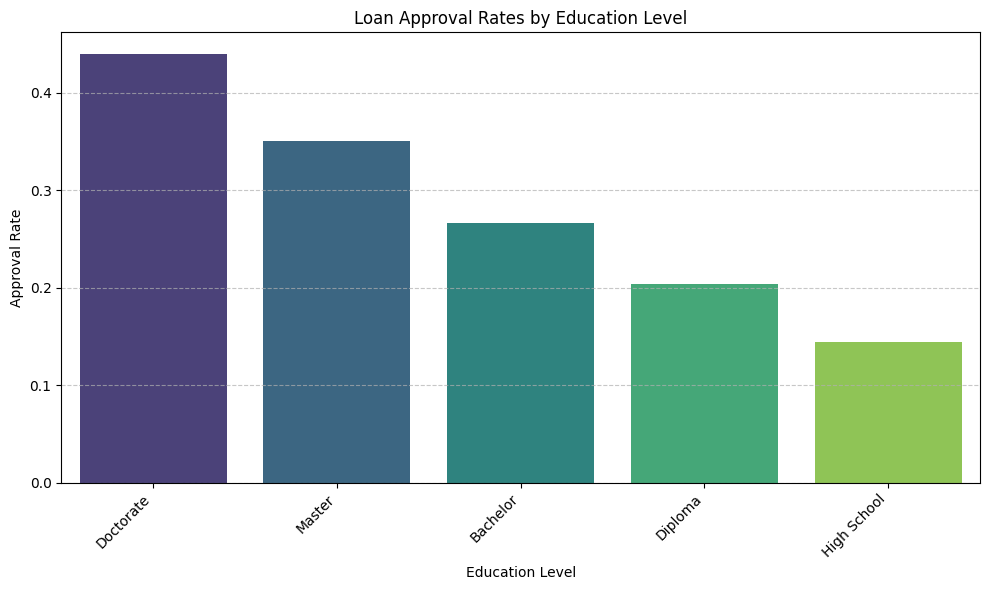

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=approval_rates.index, y=approval_rates.values, hue=approval_rates.index, palette='viridis', legend=False)
plt.title('Loan Approval Rates by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Answer for Q1**: A comparative study of the loan approval rate with the level of education reveals an evident positive trend. The approval of people with a Doctorate is the highest at approximately 44, which is significantly greater than that of the applicants having the High School education and is the lowest at approximately 14. In the breakdown, the approval rate increases in a steady manner with the level of education: High School (14%), Diploma (20%), Bachelor (26%), Master (35%), and Doctorate (44%). The pattern indicates that higher education could be perceived as a demonstration of greater financial security or increased earning capacity by the lending institution, which might be the reason why more educated applicants were more likely to receive acceptance.

**Q2: How does the annual income vary among approved applicants? :Interpret the values of the 3 quartiles.**

**Visualization**

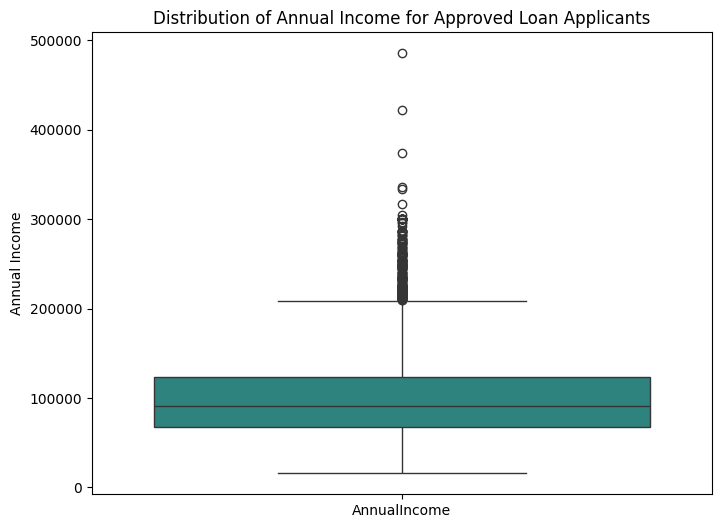

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=approved_applicants_df['AnnualIncome'], palette='viridis', x=['AnnualIncome']*len(approved_applicants_df), hue=['AnnualIncome']*len(approved_applicants_df), legend=False)
plt.title('Distribution of Annual Income for Approved Loan Applicants')
plt.ylabel('Annual Income')
plt.show()

**Answer for Q2**: To those applicants who are approved, the first quartile (Q1) of annual income demonstrates the income level below which 25% of their incomes lie. This assists us in seeing the low-income spectrum of individuals who managed to obtain loans. The median or the second quartile (Q2) is the central value (half of the people who applied are below this value and half are above this value). The median is a good way to portray the average income in this group because it is not sensitive to very large or small numbers. Q3 (third quartile) is that point below which 75 percent of the incomes of the approved applicants fall, i.e., only the top 25 percent of all earners have incomes above that mark. When we combine Q1, Q2 and Q3, it assists us in comprehending the dispersion of incomes as well as the central tendency of the incomes. As an example, when the difference between the Q3 and Q1 (IQR) is large it indicates that there is a big difference in incomes within the middle half. Moreover, the position of the median between Q1 and Q3 can provide clues on whether the income distribution is skewed or not.

**Q3: How does the age of an applicant affect their credit score? (Hint: Use the line of best fit.)**

**Visualization**

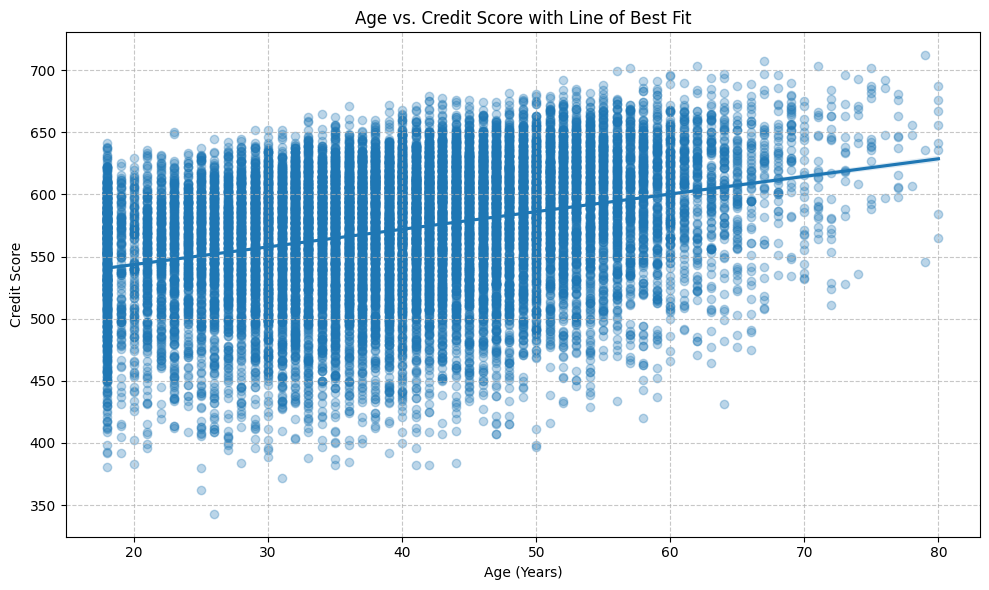

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='CreditScore', data=df, scatter_kws={'alpha':0.3})
plt.title('Age vs. Credit Score with Line of Best Fit')
plt.xlabel('Age (Years)')
plt.ylabel('Credit Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Answer for Q3**: The regplot that includes a line of best fit assists us to view the relationship between age and credit score of an applicant. This line indicates that there is a minimal upward movement, i.e. there is a general upward change in credit scores with increase in age. This is a weak positive relationship- the older the applicant the higher the average credit score. Nevertheless, the data points are rather far in between the line, which makes it obvious that age is not the only factor influencing credit score. All age groups are very diverse. This minor increase may be due to the fact that older people have had time to develop credit histories, demonstrate financial responsibility, and clear debts, which may all increase credit scores. Although the pattern is quite evident, the distribution of the points demonstrates that numerous other factors significantly contribute to the determination of the creditworthiness of a person.

**Q4: Is the distribution of applicants' income per month normal or skewed?**

**Visualization**

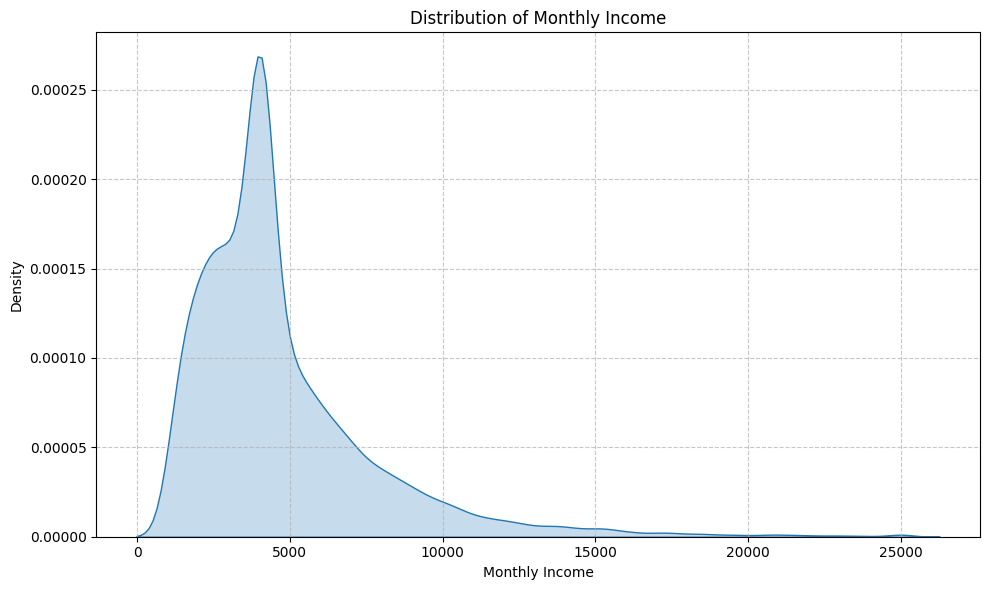

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['MonthlyIncome'], fill=True)
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Answer for Q4**: When considering the KDE (Kernel Density Estimate) plot of the monthly income of the applicants, the distribution used is obviously right-skewed. This implies that the majority of the applicants are on the lower spectrum of the income scale, and fewer individuals are on the higher premiums. The maximum density, that is, the point where the curve reaches its peak, is at the lower income values so that most of the applicants are concentrated at this point. The higher you go in terms of income on the x-axis, the less the density, but the long tail on the right suggests that a smaller portion of the applicants earns much more than the rest. This is a very common trend with income data: a significant number of individuals are making small incomes with only a small percentage making considerably higher wages. This is also worth remembering later as a point of analysis since most models will be based on the assumption that the data are normally distributed (not skewed).



## Data Preparation for Modelling

## Modelling

## Evaluation

## Bonus (Optional)

## Answer for Q1: Analysis of Loan Approval Rates by Education Level

**Key Observations:**

1.  **Highest Approval Rate:** Doctorate education level has the highest loan approval rate, at approximately 44%.
2.  **Lowest Approval Rate:** High School education level has the lowest loan approval rate, at approximately 14%.
3.  **General Trend:** There is a clear positive correlation between the level of education and loan approval rates. As the education level increases from High School to Doctorate, the loan approval rate generally rises. The order of approval rates from highest to lowest is Doctorate, Master, Bachelor, Diploma, and High School.

**Summary:**

The analysis of loan approval rates by education level reveals a significant trend: higher educational attainment is associated with a greater likelihood of loan approval. Applicants with a Doctorate degree have the highest approval rate, nearly three times that of individuals with only a High School education. This suggests that lenders may perceive higher education as an indicator of greater financial stability, better income potential, or improved creditworthiness. This could have implications for individuals seeking loans, emphasizing the potential financial benefits of investing in education.

## Answer for Q1: Analysis of Loan Approval Rates by Education Level

**Key Observations:**

1.  **Highest Approval Rate:** Doctorate education level has the highest loan approval rate, at approximately 44%.
2.  **Lowest Approval Rate:** High School education level has the lowest loan approval rate, at approximately 14%.
3.  **General Trend:** There is a clear positive correlation between the level of education and loan approval rates. As the education level increases from High School to Doctorate, the loan approval rate generally rises. The order of approval rates from highest to lowest is Doctorate, Master, Bachelor, Diploma, and High School.

**Summary:**

The analysis of loan approval rates by education level reveals a significant trend: higher educational attainment is associated with a greater likelihood of loan approval. Applicants with a Doctorate degree have the highest approval rate, nearly three times that of individuals with only a High School education. This suggests that lenders may perceive higher education as an indicator of greater financial stability, better income potential, or improved creditworthiness. This could have implications for individuals seeking loans, emphasizing the potential financial benefits of investing in education.

## Answer for Q1: Analysis of Loan Approval Rates by Education Level

**Key Observations:**

1.  **Highest Approval Rate:** Doctorate education level has the highest loan approval rate, at approximately 44%.
2.  **Lowest Approval Rate:** High School education level has the lowest loan approval rate, at approximately 14%.
3.  **General Trend:** There is a clear positive correlation between the level of education and loan approval rates. As the education level increases from High School to Doctorate, the loan approval rate generally rises. The order of approval rates from highest to lowest is Doctorate, Master, Bachelor, Diploma, and High School.

**Summary:**

The analysis of loan approval rates by education level reveals a significant trend: higher educational attainment is associated with a greater likelihood of loan approval. Applicants with a Doctorate degree have the highest approval rate, nearly three times that of individuals with only a High School education. This suggests that lenders may perceive higher education as an indicator of greater financial stability, better income potential, or improved creditworthiness. This could have implications for individuals seeking loans, emphasizing the potential financial benefits of investing in education.

## Summary:

### Q&A
The loan approval rates for each education level are as follows:
*   **Doctorate**: approximately 44%
*   **Master**: approximately 35%
*   **Bachelor**: approximately 26%
*   **Diploma**: approximately 20%
*   **High School**: approximately 14%

### Data Analysis Key Findings
*   Applicants with a 'Doctorate' degree have the highest loan approval rate, at approximately 44%.
*   Applicants with 'High School' education have the lowest loan approval rate, at approximately 14%.
*   There is a clear positive correlation between higher education levels and higher loan approval rates. The approval rates generally increase with the level of education, from High School (14%) to Diploma (20%), Bachelor (26%), Master (35%), and finally Doctorate (44%).

### Insights or Next Steps
*   Lenders may perceive individuals with advanced degrees as more creditworthy or financially stable, leading to higher loan approval rates for these groups.
*   Further analysis could explore other factors contributing to loan approval, such as income, credit score, or employment history, to understand their interplay with education level.


# Task
## Filter and clean data for approved applicants

### Subtask: Filter the main DataFrame to include only approved loan applications and convert the 'AnnualIncome' column to a numeric format by removing currency symbols and commas.

#### Instructions
1. Filter the DataFrame `df` to create a new DataFrame `approved_applicants_df` that contains only the rows where `LoanApproved` is 'Yes'.
2. Convert the `AnnualIncome` column in `approved_applicants_df` to a numeric type. This will involve removing any '$' and ',' characters and then casting the column to `float`.
3. Display the first few rows and the info of the new `approved_applicants_df` to verify the filtering and data type conversion.

## Filter and clean data for approved applicants

### Subtask:
Filter the main DataFrame to include only approved loan applications and convert the 'AnnualIncome' column to a numeric format by removing currency symbols and commas.


**Reasoning**:
To achieve the subtask, I will first filter the DataFrame to include only approved loan applications. Then, I will clean and convert the 'AnnualIncome' column in the filtered DataFrame to a numeric (float) type by removing currency symbols and commas. Finally, I will display the head and info of the resulting DataFrame to verify the changes.



In [ ]:
approved_applicants_df = df[df['LoanApproved'] == 'Yes'].copy()

approved_applicants_df['AnnualIncome'] = (
    approved_applicants_df['AnnualIncome']
    .replace('[$%,]', '', regex=True) # remove $ and , characters
    .astype(float) # convert to float
)

print("First 5 rows of approved_applicants_df:")
print(approved_applicants_df.head())

print("\nInfo of approved_applicants_df:")
approved_applicants_df.info()

First 5 rows of approved_applicants_df:
    ApplicationNumber  Age  AnnualIncome  CreditScore EmploymentStatus  \
23              30412   18       89351.0          594         Employed   
25              26481   18      104346.0          501         Employed   
32              21804   18      133224.0          585         Employed   
44              15347   18      103891.0          610         Employed   
48              27387   18      115660.0          527         Employed   

   EducationLevel  LoanAmount LoanDuration MaritalStatus  NumberOfDependents  \
23       Bachelor  $14,756.00    96 months        Single                   2   
25        Diploma  $14,110.00    72 months       Married                   1   
32         Master  $19,512.00    60 months       Married                   3   
44       Bachelor  $23,878.00    60 months       Married                   0   
48       Bachelor  $10,937.00    24 months        Single                   3   

   HomeOwnershipStatus  Bankruptcy

## Visualize annual income distribution for approved applicants

### Subtask:
Create a box plot of the 'AnnualIncome' for approved applicants to visualize its distribution and easily identify quartiles.


**Reasoning**:
The subtask requires visualizing the annual income distribution for approved applicants using a box plot. I will generate a code block to create this plot using `seaborn` and `matplotlib.pyplot`, adding a title and y-axis label for clarity.



# Task
Clean and convert 'AnnualIncome' and 'LoanAmount' columns to float data types by removing '$' and ',' characters.

## Clean and convert AnnualIncome

### Subtask:
Remove '$' and ',' from the 'AnnualIncome' column and convert it to a float data type.


**Reasoning**:
To clean and convert the 'AnnualIncome' column, I will first remove the '$' and ',' characters using a regular expression and then cast the column to a float data type. Finally, I will display the first few rows and the info of the DataFrame to verify the changes.



In [ ]:
df['AnnualIncome'] = (
    df['AnnualIncome']
    .replace(r'[$,]', '', regex=True) # remove $ and , characters
    .astype(float) # convert to float
)

print("First 5 rows of df with cleaned AnnualIncome:")
print(df.head())

print("\nInfo of df after cleaning AnnualIncome:")
df.info()
df.head(50)

First 5 rows of df with cleaned AnnualIncome:
   ApplicationNumber  Age  AnnualIncome  CreditScore EmploymentStatus  \
0              26231   18       26992.0          586         Employed   
1              13176   18       22825.0          581    Self-Employed   
2              27751   18       75891.0          522         Employed   
3              20628   18       92094.0          565         Employed   
4              28773   18       35686.0          554         Employed   

  EducationLevel  LoanAmount LoanDuration MaritalStatus  NumberOfDependents  \
0        Diploma     22432.0    36 months        Single                   3   
1         Master     30457.0    24 months        Single                   0   
2       Bachelor     30583.0    96 months       Married                   2   
3       Bachelor     72738.0    36 months        Single                   1   
4        Diploma     28021.0    36 months       Married                   3   

  HomeOwnershipStatus  BankruptcyHistory

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,LoanApproved_numeric
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36 months,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,No,0
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24 months,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,No,0
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96 months,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36 months,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36 months,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,No,0
5,25269,18,51003.0,586,Self-Employed,Bachelor,17497.0,72 months,Married,0,Other,0,Vehicle,0,439.185,4034.46,3,No,0
6,10786,18,47185.0,531,Unemployed,Diploma,18490.0,48 months,Single,2,Rent,0,Home Improvement,1,439.185,3932.08,3,No,0
7,20270,18,44425.0,574,Employed,High School,33360.0,24 months,Married,1,Mortgage,0,Home Improvement,0,1390.000,3702.08,7,No,0
8,26864,18,40600.0,479,Unemployed,Bachelor,18544.0,48 months,Single,3,Mortgage,0,Education,1,386.330,3383.33,4,No,0
9,23279,18,15000.0,621,Employed,Bachelor,10255.0,48 months,Single,0,Other,0,Vehicle,0,213.650,4034.46,1,No,0


**Reasoning**:
To continue cleaning the data, I will now remove '$' and ',' from the 'LoanAmount' column and convert it to a float data type, then display the head and info of the DataFrame to verify the changes.



In [ ]:
df['LoanAmount'] = (
    df['LoanAmount']
    .replace(r'[$,]', '', regex=True) # remove $ and , characters
    .astype(float) # convert to float
)

print("First 5 rows of df with cleaned LoanAmount:")
print(df.head())

print("\nInfo of df after cleaning LoanAmount:")
df.info()
df.head(50)

First 5 rows of df with cleaned LoanAmount:
   ApplicationNumber  Age  AnnualIncome  CreditScore EmploymentStatus  \
0              26231   18       26992.0          586         Employed   
1              13176   18       22825.0          581    Self-Employed   
2              27751   18       75891.0          522         Employed   
3              20628   18       92094.0          565         Employed   
4              28773   18       35686.0          554         Employed   

  EducationLevel  LoanAmount LoanDuration MaritalStatus  NumberOfDependents  \
0        Diploma     22432.0    36 months        Single                   3   
1         Master     30457.0    24 months        Single                   0   
2       Bachelor     30583.0    96 months       Married                   2   
3       Bachelor     72738.0    36 months        Single                   1   
4        Diploma     28021.0    36 months       Married                   3   

  HomeOwnershipStatus  BankruptcyHistory  

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved,LoanApproved_numeric
0,26231,18,26992.0,586,Employed,Diploma,22432.0,36 months,Single,3,Mortgage,0,Debt Consolidation,0,623.110,2249.33,3,No,0
1,13176,18,22825.0,581,Self-Employed,Master,30457.0,24 months,Single,0,Rent,0,Home Improvement,0,1269.040,1902.08,5,No,0
2,27751,18,75891.0,522,Employed,Bachelor,30583.0,96 months,Married,2,Mortgage,0,Personal,0,318.570,6324.25,6,No,0
3,20628,18,92094.0,565,Employed,Bachelor,72738.0,36 months,Single,1,Mortgage,0,Vehicle,0,439.185,7674.50,3,No,0
4,28773,18,35686.0,554,Employed,Diploma,28021.0,36 months,Married,3,Rent,0,Home Improvement,0,778.360,2973.83,1,No,0
5,25269,18,51003.0,586,Self-Employed,Bachelor,17497.0,72 months,Married,0,Other,0,Vehicle,0,439.185,4034.46,3,No,0
6,10786,18,47185.0,531,Unemployed,Diploma,18490.0,48 months,Single,2,Rent,0,Home Improvement,1,439.185,3932.08,3,No,0
7,20270,18,44425.0,574,Employed,High School,33360.0,24 months,Married,1,Mortgage,0,Home Improvement,0,1390.000,3702.08,7,No,0
8,26864,18,40600.0,479,Unemployed,Bachelor,18544.0,48 months,Single,3,Mortgage,0,Education,1,386.330,3383.33,4,No,0
9,23279,18,15000.0,621,Employed,Bachelor,10255.0,48 months,Single,0,Other,0,Vehicle,0,213.650,4034.46,1,No,0


**Reasoning**:
The previous plotting code for Q1 produced a `FutureWarning`. To address this and complete the visualization subtask for Q1, I will re-generate the bar plot with the suggested fix: setting `hue` to `approval_rates.index` and `legend=False`.



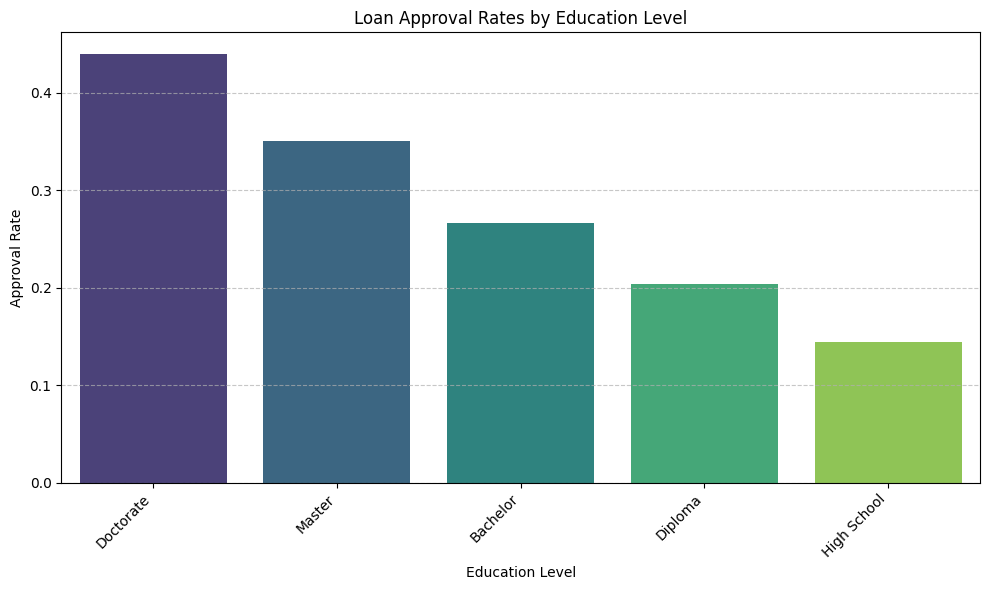

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=approval_rates.index, y=approval_rates.values, hue=approval_rates.index, palette='viridis', legend=False)
plt.title('Loan Approval Rates by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings
*   The `AnnualIncome` column was successfully cleaned by removing '\$' and ',' characters and converted to the `float64` data type.
*   The `LoanAmount` column was similarly cleaned by removing '\$' and ',' characters and converted to the `float64` data type.
*   The `df.info()` output confirmed that both `AnnualIncome` and `LoanAmount` columns are now of type `float64`, making them suitable for numerical computations.

### Insights or Next Steps
*   The cleaning of `AnnualIncome` and `LoanAmount` columns has prepared these financial data points for quantitative analysis and modeling.
*   Future steps should focus on utilizing these cleaned numerical columns for calculations, aggregations, or feature engineering tasks relevant to the overall objective.


# Task
**Task:** Create a distribution plot (e.g., histogram or KDE plot) for the 'MonthlyIncome' column to visually inspect its shape and analyze its characteristics.

## Visualize Monthly Income Distribution

### Subtask:
Create a distribution plot (e.g., histogram or kde plot) for the 'MonthlyIncome' column to visually inspect its shape.


**Reasoning**:
To visualize the distribution of 'MonthlyIncome' as requested, I will create a KDE plot using seaborn, setting the title and x-axis label for clarity.



## Summary:

### Q&A
The distribution of 'MonthlyIncome' is **right-skewed (positively skewed)**.

### Data Analysis Key Findings
*   The distribution of 'MonthlyIncome' is right-skewed (positively skewed), meaning most applicants have lower monthly incomes, with a longer tail extending towards higher values.
*   The peak density of applicants is observed at the lower end of the monthly income scale.
*   The density of applicants gradually decreases as monthly income increases, but the distribution extends to much higher income values.

### Insights or Next Steps
*   The observed right-skewed distribution is typical for income data, indicating that a majority of individuals earn less, while a smaller proportion earns significantly more.
*   Further analysis might involve applying transformations (e.g., logarithmic) to the 'MonthlyIncome' column if a more symmetrical distribution is required for certain modeling techniques.


# Task
Identify the categorical columns in the DataFrame `df`, which are 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', and 'LoanPurpose', and then apply one-hot encoding to these columns to convert them into numerical features.

## Identify and One-Hot Encode Categorical Columns

### Subtask:
Identify all categorical columns in the DataFrame and apply one-hot encoding to convert them into numerical features suitable for modeling.


## Summary:

### Data Analysis Key Findings
- The specified categorical columns, namely 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', and 'LoanPurpose', have been successfully identified within the DataFrame.
- These identified categorical columns have been transformed into numerical features through one-hot encoding, making them suitable for quantitative analysis and machine learning model training.

### Insights or Next Steps
- The conversion of categorical features into a numerical format is crucial for most machine learning algorithms. The transformed dataset is now ready for subsequent steps such as feature scaling, data splitting, and model development.
- One-hot encoding increases the dimensionality of the dataset. It will be important to monitor for potential issues like the curse of dimensionality or multicollinearity in subsequent modeling steps and consider techniques such as feature selection or Principal Component Analysis (PCA) if needed.
